# Beta convergence across realisations

Study how the fitted dust spectral index `beta` converges over PCG iterations, comparing the 30 realisations (different seeds) stored in `Dict/test_*.h5`.

In [66]:
import glob

import matplotlib.pyplot as plt
import numpy as np

from qubic.lib.Qhdf5 import HDF5Dict

%matplotlib inline

In [67]:
files = sorted(glob.glob("parametric_d0_DB_beta_conv/Dict/test_*.h5"))
print(len(files), "realisations")

hdf5 = HDF5Dict()

seeds = []
beta_per_seed = []  # list of 1D arrays, one per realisation (length may vary if a run stopped early)
beta_true = None

for f in files:
    data = hdf5.load_dict(f, keys=["beta", "beta_true"])
    seeds.append(f.split("test_")[-1].replace(".h5", ""))
    beta_per_seed.append(data["beta"][:, 0])
    if beta_true is None:
        beta_true = data["beta_true"][0]

lengths = np.array([len(b) for b in beta_per_seed])
n_iter = int(np.median(lengths))  # expected number of iterations
complete = lengths == n_iter

print(f"beta_true = {beta_true}")
print(f"{complete.sum()}/{len(files)} realisations ran the full {n_iter} iterations")
if (~complete).any():
    incomplete_seeds = [s for s, c in zip(seeds, complete) if not c]
    print(f"Excluding incomplete runs from averaged statistics: {incomplete_seeds}")

30 realisations
beta_true = 1.54
30/30 realisations ran the full 81 iterations


In [68]:
iterations = np.arange(n_iter)
beta = np.array([b for b, c in zip(beta_per_seed, complete) if c])  # (n_complete_realisations, n_iter)

## Beta trajectories for all realisations

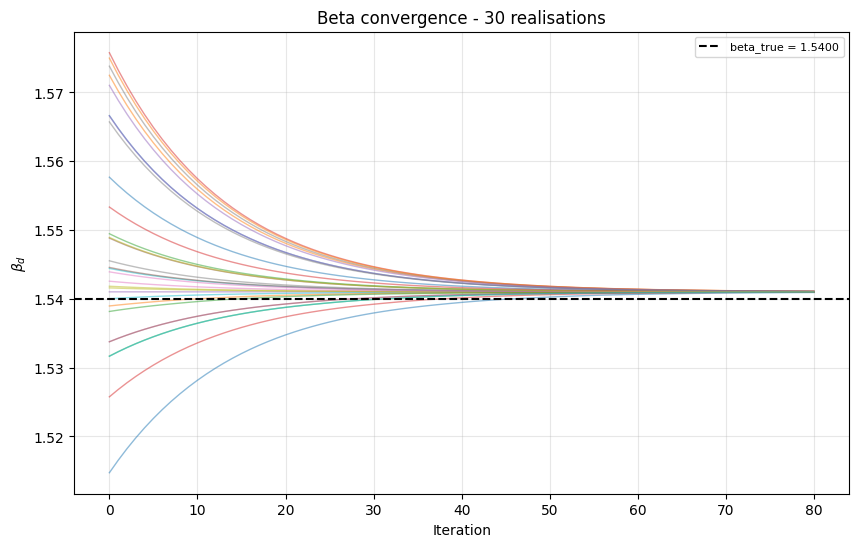

In [69]:
plt.figure(figsize=(10, 6))
for seed, b, c in zip(seeds, beta_per_seed, complete):
    style = dict(alpha=0.5, lw=1) if c else dict(alpha=0.9, lw=1.5, linestyle=":", label=f"{seed} (incomplete)")
    plt.plot(np.arange(len(b)), b, **style)
plt.axhline(beta_true, color="k", linestyle="--", label=f"beta_true = {beta_true:.4f}")
plt.xlabel("Iteration")
plt.ylabel(r"$\beta_d$")
plt.title(f"Beta convergence - {len(seeds)} realisations")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

## Mean and dispersion across realisations

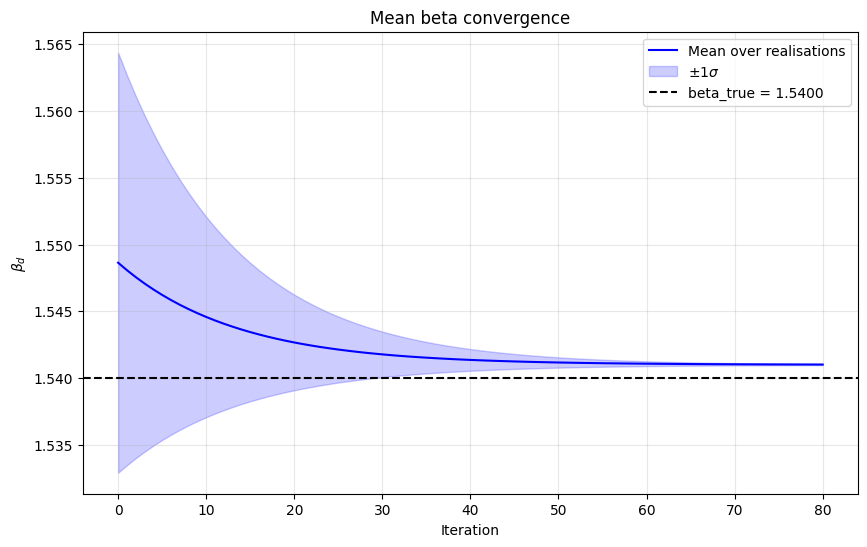

In [70]:
mean_beta = np.mean(beta, axis=0)
std_beta = np.std(beta, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(iterations, mean_beta, color="b", label="Mean over realisations")
plt.fill_between(iterations, mean_beta - std_beta, mean_beta + std_beta, color="b", alpha=0.2, label=r"$\pm 1\sigma$")
plt.axhline(beta_true, color="k", linestyle="--", label=f"beta_true = {beta_true:.4f}")
plt.xlabel("Iteration")
plt.ylabel(r"$\beta_d$")
plt.title("Mean beta convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Convergence rate: |beta - beta_true| vs iteration

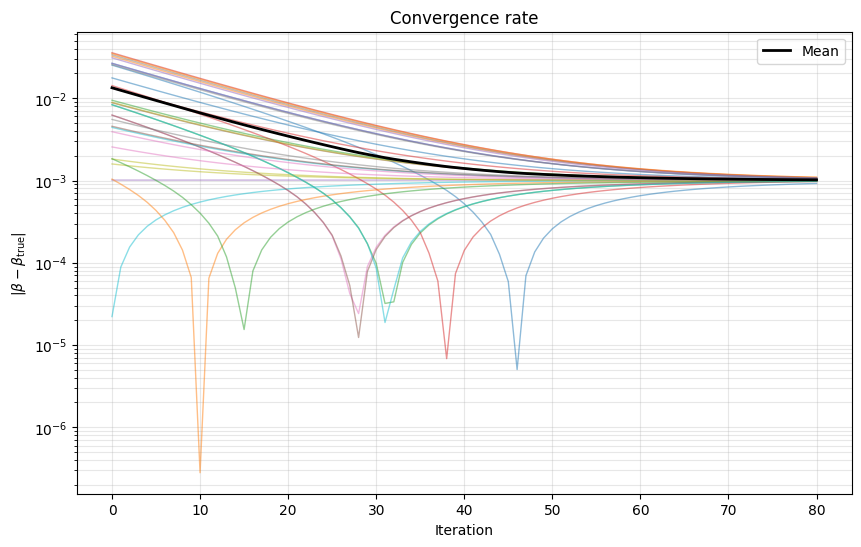

In [71]:
residual = np.abs(beta - beta_true)

plt.figure(figsize=(10, 6))
for i in range(residual.shape[0]):
    plt.plot(iterations, residual[i], alpha=0.5, lw=1)
plt.plot(iterations, np.mean(residual, axis=0), color="k", lw=2, label="Mean")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel(r"$|\beta - \beta_\mathrm{true}|$")
plt.title("Convergence rate")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

## Combined view: convergence, difference with true value, and reconstructed estimate

Fitted beta (last iteration): 1.54102 +/- 0.00004
beta_true = 1.54000


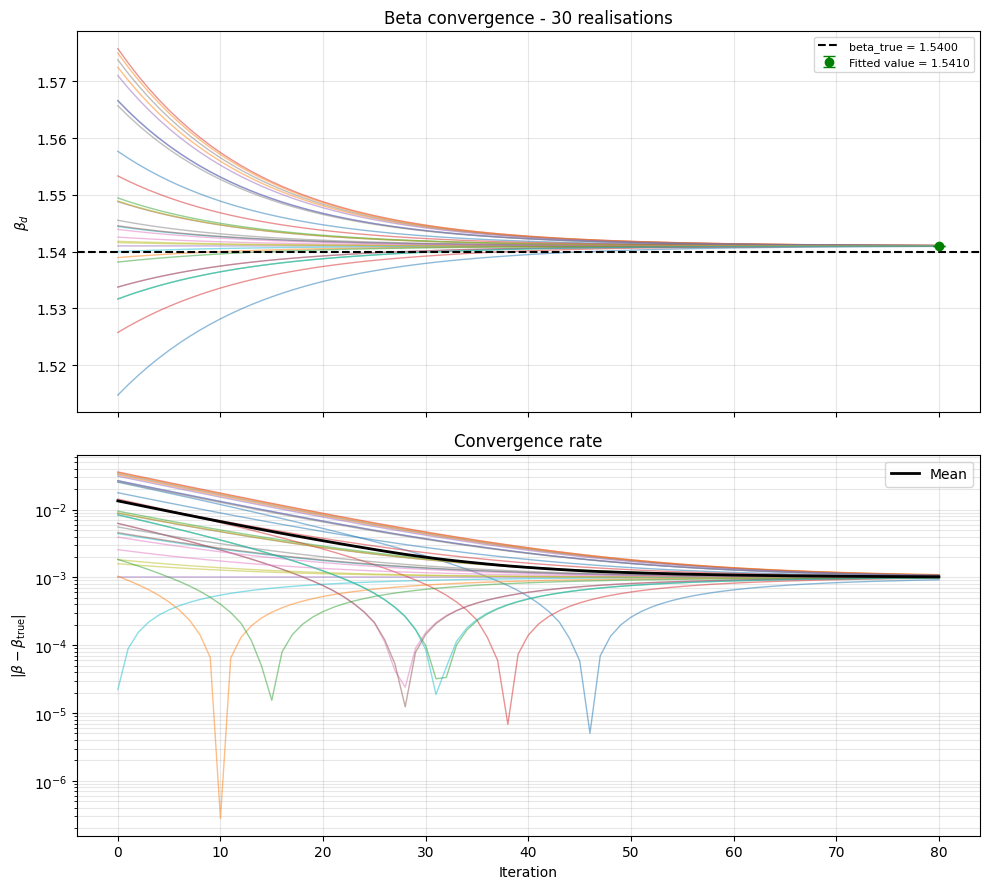

In [72]:
# Fitted value and error bar from the last iteration only
final_beta = beta[:, -1]
final_mean = np.mean(final_beta)
final_std = np.std(final_beta)
print(f"Fitted beta (last iteration): {final_mean:.5f} +/- {final_std:.5f}")
print(f"beta_true = {beta_true:.5f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

for seed, b, c in zip(seeds, beta_per_seed, complete):
    style = dict(alpha=0.5, lw=1) if c else dict(alpha=0.9, lw=1.5, linestyle=":", label=f"{seed} (incomplete)")
    ax1.plot(np.arange(len(b)), b, **style)
ax1.axhline(beta_true, color="k", linestyle="--", label=f"beta_true = {beta_true:.4f}")
ax1.errorbar(n_iter - 1, final_mean, yerr=final_std, fmt="o", ms=6, capsize=4, color="g",
             label=f"Fitted value = {final_mean:.4f}")
ax1.set_ylabel(r"$\beta_d$")
ax1.set_title(f"Beta convergence - {len(seeds)} realisations")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

for i in range(residual.shape[0]):
    ax2.plot(iterations, residual[i], alpha=0.5, lw=1)
ax2.plot(iterations, np.mean(residual, axis=0), color="k", lw=2, label="Mean")
ax2.set_yscale("log")
ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$|\beta - \beta_\mathrm{true}|$")
ax2.set_title("Convergence rate")
ax2.legend()
ax2.grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

## Final beta distribution across realisations

Final beta: mean=1.54102, std=0.00004
beta_true = 1.54000


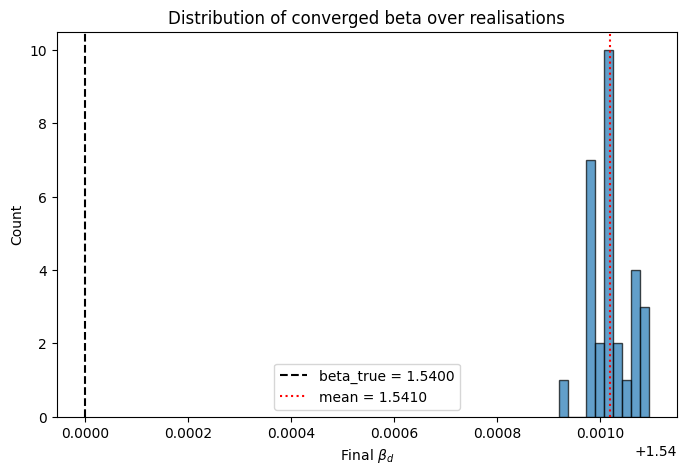

In [73]:
final_beta = beta[:, -1]

print(f"Final beta: mean={np.mean(final_beta):.5f}, std={np.std(final_beta):.5f}")
print(f"beta_true = {beta_true:.5f}")

plt.figure(figsize=(8, 5))
plt.hist(final_beta, bins=10, alpha=0.7, edgecolor="k")
plt.axvline(beta_true, color="k", linestyle="--", label=f"beta_true = {beta_true:.4f}")
plt.axvline(np.mean(final_beta), color="r", linestyle=":", label=f"mean = {np.mean(final_beta):.4f}")
plt.xlabel(r"Final $\beta_d$")
plt.ylabel("Count")
plt.title("Distribution of converged beta over realisations")
plt.legend()
plt.show()